# Pioneer Feature Calculation Pipeline

In [1]:
# General imports
import os, sys
import mne

mne.set_log_level('ERROR')

# paths
working_dir = os.path.abspath("")
sys.path.append(working_dir)

from utils import *

all_settings = {'yasa': {'win':int(5*60), 'stride':int(5*60), 
                        'reref':'CAR', 'pre_whiten':False,
                        'resample':100, 'lowcut':0.4, 'highcut':30},
                'adratio':{'win':int(60), 'stride':int(60), 
                        'reref':'CAR', 'pre_whiten':False},
                'spike': {'win':int(60), 'stride':int(60),
                            'reref':'CAR', 'pre_whiten':False},
                'synchrony':{'win':int(60), 'stride':int(60),
                            'reref':'CAR', 'pre_whiten':False},
                'sparcnet': {'win':int(10), 'stride':int(2),
                            'reref':'BIPOLAR', 'pre_whiten': False,
                            'resample':200, 'lowcut':1, 'highcut':40},
                'wvnt':{'win':1, 'stride':0.5,
                        'reref':'BIPOLAR','pre_whiten': True,'resample':128}}

In [2]:
# read sample data
edf_file_path = 'YASA/EMU1371_Day02_1_5006_to_5491.edf'
raw = mne.io.read_raw_edf(edf_file_path, preload=True)
fs = raw.info['sfreq']
raw_df = raw.to_data_frame()
raw_df['stamp'] = np.arange(1,raw_df.shape[0]+1)
raw_df.set_index(['time','stamp'],inplace=True)
info = {'sampling_freq':fs, 'sampling_freq_raw':fs, 'channel_names':raw.ch_names, 'study_type': 'eeg'}
# probably best to convert sample stamps to time in seconds from the start of the recording
# there could be another function maps second lapse to actual clock time

## Preprocessing

For Azure run:

Set a preprocessing job run every x seconds

For each active patient:
* Initiate a processor with batch size specified as 1/2/5/10? seconds, fit the info data
* Check the last sample/batch_index available for this patient in the processed database
* Grab all data after the last sample
* Continue if no new data
* Do `preprocess(data, last_batch_index)`
* The function would automatically separate data into multiple batches of specified batch size
* Batch size would affect bad channel and artifact detection, i.e. the bad channel and artifact judgement are in unit of batches 
* Add a write to database function to save processed batch to database

Things to note:
* There could be jumps in samples, e.g. 3000 to 300000. 
* The timestamps are not accurate, and are generated upon receiving the sample, so there could be lagging in timestamp and variations in lags? And use this as a range limit might cause +/-1 variations in sample number?
* So I decided to use batch size*sampling rate to get fixed number of samples for each batch 
* The issues then turns to be jumps in samples, e.g. suppose the samplestamp range is 3000 to 6000, if the samples from 4000 to 4500 are missing, such incontinuity might cause some issue? 
* Need to figure out what we what to do for such incontinuity, and suppose there're breaks, whether we want to keep consistent batching, or start from the new available sample

In [ ]:
class Preprocessor():
    """
    Do basic preprocessing for a data batch
    1. Bandpass filter 0.5-100 Hz
    2. Notch filter 60 Hz
    3. Detect bad channels, if more than 20% of channels are bad, mark as a potential artifact
    4. Downsample to 256 Hz (optional)
    5. Re-reference (CAR and bipolar), for CAR, bad channels are excluded in calculating mean, bad channel indices are provided
    6. Pre-whiten (if True)
    7. Return the processed data in data frame, with other metadata saved in a dictionary

    User can retrieve either the re-refed data, or other metadata fields through get_last_packet method.
    
    Note for interface with Azure, can insert database writing after filter, two re-referencing, and pre-whiten, and also for bad masks
    May need a "patient" column to specify which patient the data is from
    """
    def __init__(self, lowcut = 0.5, highcut = 100, artifact_perc = 0.2, batch_size = 1):
        self.chs = None
        self.n_chs = None
        self.lowcut = lowcut
        self.highcut = highcut
        # removed downsample temporarily, I think the SDK and the headbox type available naturally makes all EEG data 256 Hz
        # and iEEG data 512 Hz
        # self.down_fs = down_fs 
        self.artifact_perc = artifact_perc
        self.batch_size = batch_size
        self.bad_channels = None
        self.fitted = False
        self.last_packet = None

    def _filter_data(self, data):
        # bandpass filter
        data = bandpass_filter(data, self.fs, lo = self.lowcut, hi = self.highcut)
        data = notch_filter(data, self.fs)
        return data

    def fit(self, info):
        self.fs = info['sampling_freq']
        self.fs_raw = info['sampling_freq_raw']
        
        self.batch_sample_raw = int(self.fs_raw*self.batch_size) 
        self.batch_sample = int(self.fs*self.batch_size)
        self.sample_step = self.batch_sample_raw//self.batch_sample
        
        self.chs = clean_labels(info['channel_names'])
        self.nchs = len(self.chs)
        self.type = info['study_type']
        self.ch_type = check_channel_type(self.chs)
        self.ieeg_idx = [True if i == 'ieeg' else False for i in self.ch_type ]
        self.eeg_idx = [True if i == 'eeg' else False for i in self.ch_type ]
        self.ekg_idx = [True if i == 'ekg' else False for i in self.ch_type ]
        self.eog_idx = [True if i == 'eog' else False for i in self.ch_type ]
        if self.type.lower() == 'ieeg':# not sure what's the code for intracranial
            self.nchs_eeg = np.sum(self.ieeg_idx)
            self.bipolar_labels, self.bipolar_idx = bipolar_montage_ieeg(self.chs[self.ieeg_idx])
            self.nchs_bipolar = len(self.bipolar_labels)
            self.down_fs = 512
        elif self.type.lower() == 'eeg':
            self.nchs_eeg = np.sum(self.eeg_idx)
            self.bipolar_labels, self.bipolar_idx = bipolar_montage_eeg(self.chs[self.eeg_idx])
            self.nchs_bipolar = len(self.bipolar_labels)
            self.down_fs = 256
        self.fitted = True

    def get_batches(self, data, last_batch_ind):
        """
        Add an index with title batch to the data dataframe
        """
        # need to check this, if the raw sampling freq is 1024 and the transmission sampling freq is 512,
        # the stamp samples may not be consecutive
        # the batch_starts should be from the original sample freq
        batch_starts = np.arange(data.index[0][1],data.index[-1][1],self.batch_sample_raw) # use raw batch sample number to set stamp sample range
        stamps = data.index.get_level_values('stamp').values
        inds = np.digitize(stamps, batch_starts, right = False)
        batch_indices = np.squeeze(last_batch_ind+inds)
        unique_batch = sorted(np.unique(batch_indices))
        data_copy = data.copy()
        data_copy['batch'] = batch_indices
        data_copy = data_copy.set_index('batch',append=True)
        # use batch sample number to check if the last batch is full, if not, leave the last batch for next round
        # in this way, at the end of processing, the last batch, whether full or not, need to be processed
        batches = [data_copy.iloc[batch_indices == batch,:] for batch in unique_batch]
        batches = [batch for batch in batches if batch.shape[0] == self.batch_sample] # can change to maximum allowed size for filters
        return batches
    
    def preprocess(self, data, last_batch_ind):
        """
        Do actual preprocess. 

        Args:
            data (pd.Dataframe): A pd.dataframe with columns being channel names, and two index, the first being seconds from start, the second being stamps
            last_batch_ind (int): An index for last available batch to make indexing consecutive
            ref (_type_, optional): _description_. Defaults to None.

        Returns:
            _type_: _description_
        """
        assert self.fitted == True, "Processor not fitted yet"
        assert data.shape[1] == self.nchs, "Data has different number of channels than fitted processor"
        batches = self.get_batches(data, last_batch_ind)
        artifact = False
        artifact_perc = 0
        # if isinstance(data, pd.DataFrame):
        #     timestamps = data.index
        #     data = data.values
        # else:
        #     timestamps = np.arange(data.shape[0])/self.fs
        packets = []
        for batch in batches:
        # downsample
            batch_ind = batch.index[0][2]
            data = batch.values
            index = batch.index

            # removed downsample temporarily, I think the SDK and the headbox type available naturally makes all EEG data 256 Hz
            # and iEEG data 512 Hz
            # if self.fs > self.down_fs:
            #     data = downsample(data, self.fs, self.down_fs)
            #     timestamps = downsample(timestamps, self.fs, self.down_fs)

            processed = self._filter_data(data)
            raw_filtered = pd.DataFrame(processed, columns=self.chs, index=index)

            if self.type == 'ieeg':
                eeg_data = processed[:,self.ieeg_idx]
                eeg_chs = self.chs[self.ieeg_idx]
                bad_mask, details  = detect_bad_channels(eeg_data, self.fs)
            elif self.type == 'eeg':
                eeg_data = processed[:,self.eeg_idx]
                eeg_chs = self.chs[self.eeg_idx]
                bad_mask, details  = detect_bad_channels_eeg(eeg_data, self.fs)
            artifact_perc = np.sum(bad_mask == False)/self.nchs
            if artifact_perc > self.artifact_perc:
                artifact = True

            # re-reference
            # CAR
            car_data = eeg_data - np.mean(eeg_data[:,bad_mask], axis = 1)[:,np.newaxis]
            
            # BIPOLAR
            bad_ind = np.where(~bad_mask)[0]
            if self.type == 'ieeg':
                tmp_bipolar_index = self.bipolar_idx.copy()
                # tmp_bipolar_index[np.isin(tmp_bipolar_index,bad_ind)] = np.nan
                for i, ch in enumerate(tmp_bipolar_index):
                    if np.isin(ch[1],bad_ind) and not np.isin(ch[2],bad_ind):
                        tmp_bipolar_index[i,1] = tmp_bipolar_index[i,2]
                bipolar_data = eeg_data[:,tmp_bipolar_index[:,0]] - eeg_data[:,tmp_bipolar_index[:,1]]
                bad_mask_bipolar = np.any(np.isin(tmp_bipolar_index[:,:1],bad_ind),axis=1)
            else:
                bipolar_data = eeg_data[:,self.bipolar_idx[:,0]] - eeg_data[:,self.bipolar_idx[:,1]]
                bad_mask_bipolar = ~np.any(np.isin(self.bipolar_idx,bad_ind),axis=1)

            car_data_df = pd.DataFrame(car_data, columns = eeg_chs, index=index)
            bipolar_data_df = pd.DataFrame(bipolar_data, columns = self.bipolar_labels, index=index)

            car_data_prewhite = pd.DataFrame(pre_whiten(car_data), columns = eeg_chs, index=index)
            bipolar_data_prewhite = pd.DataFrame(pre_whiten(bipolar_data), columns = self.bipolar_labels, index=index)

            ekg_data = pd.DataFrame(processed[:,self.ekg_idx], columns = self.chs[self.ekg_idx], index=index)
            eog_data = pd.DataFrame(processed[:,self.eog_idx], columns = self.chs[self.eog_idx], index=index)

            car_bad = pd.DataFrame(bad_mask.reshape(1,-1), columns=eeg_chs, index=pd.Index([batch_ind],name='batch'))
            bipolar_bad = pd.DataFrame(bad_mask_bipolar.reshape(1,-1), columns=self.bipolar_labels, index=pd.Index([batch_ind],name='batch'))
            artifact = pd.DataFrame(artifact, index = pd.Index([batch_ind], name='batch'), columns = ['artifact'])
            artifact_perc = pd.DataFrame(artifact_perc, index = pd.Index([batch_ind], name='batch'), columns = ['artifact_perc'])

            packet = {'raw': data, 'raw_fs': self.fs, 
                                'filtered':raw_filtered, 'fs': self.down_fs,
                                'bad_mask': bad_mask, 'bad_details': details, 
                                'artifact': artifact, 'artifact_perc': artifact_perc,
                                'CAR': car_data_df, 'BIPOLAR': bipolar_data_df, 
                                'CAR_prewhite': car_data_prewhite, 'BIPOLAR_prewhite': bipolar_data_prewhite,
                                'CAR_bad': car_bad, 'BIPOLAR_bad': bipolar_bad,
                                'EKG':ekg_data, 'EOG': eog_data}
            
            packets.append(packet)
            # change to database writing here
            
        return packets
    
    # def fit_preprocess(self, data, fs, ref = None):
    #     self.fit(data,fs)
    #     processed_dict = self.preprocess(data)
    #     if ref == 'bipolar':
    #         return processed_dict['BIPOLAR']
    #     elif ref == 'car':
    #         return processed_dict['CAR']
    #     else:
    #         return processed_dict

    # def get_last_packet(self, field = None):
    #     if field:
    #         return self.last_packet[field]
    #     return self.last_packet


In [4]:
prepro = Preprocessor(batch_size=30)
prepro.fit(info)
processed_packets = prepro.preprocess(raw_df, last_batch_ind=0)

In [5]:
data_fields = ['filtered', 'CAR', 'BIPOLAR', 'CAR_prewhite', 'BIPOLAR_prewhite', 'EKG', 'EOG']
batch_fields = ['CAR_bad', 'BIPOLAR_bad', 'artifact', 'artifact_perc']
data_dfs = {i: pd.DataFrame() for i in data_fields}
batch_dfs = {i: pd.DataFrame() for i in batch_fields}
for packet_ind, data in enumerate(processed_packets):
    for field in data_fields:
        data_dfs[field] = pd.concat([data_dfs[field], data[field]])
    for field in batch_fields:
        batch_dfs[field] = pd.concat([batch_dfs[field], data[field]])

Feature calculation for Azure run:

Set a preprocessing job for each feature that run every x seconds
x should be equal to or longer than the feature stride

For each active patient:
* Initiate a clip loader, with feature win, stride, reference, whether prewhiten specified
* Need to decide whether feature timestamp is left/right aligned, maybe right for now
* Check the last sample available for this feature and this patient in the feature database
* Grab all data after the last sample
* Continue if no new data
* Do preprocess(data, last_batch_index)
* Add a write to database function to save processed batch to database

In [ ]:
# self.data_dfs = pd.concat(data_dfs.values(), axis=1)
# self.data_dfs.columns = pd.MultiIndex.from_tuples(
#     [(i, j) for i in data_dfs.keys() for j in data_dfs[i].columns]
#     )
# self.batch_dfs = pd.concat(batch_dfs.values(), axis=1)
# self.batch_dfs.columns = pd.MultiIndex.from_tuples(
#     [(i, j) for i in batch_dfs.keys() for j in batch_dfs[i].columns]
#     )

# def _update_dfs(self):
#     """
#     This should reload dfs
#     TODO whether it's time consuming to load all data from one patient in
#     If so, should only update data after time x
#     """
#     last_time = self.data_dfs.index[-1]
#     last_batch = self.batch_dfs.index[-1]
#     # query data after this and append to self.data_dfs
#     # query batches after this and append to self.batch_dfs
#     self._update_time_info()

# pseudo pipeline
# feat_name = 'feat'
# aligned = 'right'
# for patient in active_patients:
#     info = get_info(patient)
#     clip_loader = DatabaseFeatLoader(patient, feat_name, aligned)
#     for index, clip, bad_mask in clip_loader:
#         feat_single(clip,bad_mask)
        

In [7]:
class ClipLoader:
    """
    A clip loader serves feature calculation. It links to processed database and provides new clips for each feature function.
    One clip loader should be created per feature per patient. 

    TODO: How to deal with artifacts?
    """
    def __init__(self, info, feat_win = 5, feat_stride = 0, ref = 'CAR', pre_whiten = False, aligned = 'right', reject_art = False):
        
        self.info = info
        self.fs = info['sampling_freq']
        self.fs_raw = info['sampling_freq_raw']
        self.sample_step = self.fs_raw//self.fs
        self.feat_win = feat_win
        self.feat_stride = feat_stride
        self.win_sample = int(self.feat_win*self.fs)
        self.win_sample_raw = int(self.feat_win*self.fs_raw)
        self.stride_sample = int(self.feat_stride*self.fs)
        self.stride_sample_raw = int(self.feat_stride*self.fs_raw)
        self.ref = ref
        self.prewhite = pre_whiten
        self.aligned = aligned
        self._set_data_key()
    
    def _set_data_key(self):
        self.data_key = self.ref
        if self.ref == 'filtered':
            self.bad_key = 'CAR_bad'
        else:
            if self.prewhite:
                self.data_key += '_prewhite'
            self.bad_key = self.ref + '_bad'

    def set_ref(self, ref):
        self.ref = ref
        self._set_data_key()

    def set_prewhite(self, pre_whiten):
        self.prewhite = pre_whiten
        self._set_data_key()

    def set_feat_win(self, feat_win):
        self.feat_win = feat_win

    def set_feat_stride(self, feat_stride):
        self.feat_stride = feat_stride

    def set_data(self, data, batch_dfs):
        self.data = data[self.data_key]
        self.bad_mask = batch_dfs[self.bad_key]
        self.win_start = self.data.index[0][1]
        self.stamp_end = self.data.index[-1][1]
    
    def __iter__(self):
        return self

    def __next__(self):
        """
        Allows iteration over batches.
        """
        win_stop = self.win_start + self.win_sample_raw - 1
        if win_stop > self.stamp_end:
            raise StopIteration  # Stop when limit is reached
        clip_data = self.data.query(f'{self.win_start} <= stamp <= {win_stop}')
        self.win_start = self.win_start + self.stride_sample_raw
        if self.aligned == 'right':
            feat_index = pd.MultiIndex.from_tuples([clip_data.index[-1][:2]],names=['time','stamp'])
        elif self.aligned == 'left':
            feat_index = pd.MultiIndex.from_tuples([clip_data.index[0][:2]],names=['time','stamp'])
        bad_mask = pd.DataFrame(index=clip_data.index.get_level_values('batch')).merge(self.bad_mask,left_index=True,right_index=True, how = 'left')
        bad_mask = np.squeeze(((bad_mask == False).mean() <= 0.2).to_numpy())
        if np.sum(bad_mask == False) > 0.2 and self.reject_artifact:
            artifact = True
            return self.__next__()
        else:
            artifact = False
            return feat_index, clip_data, bad_mask

class DatabaseFeatLoader(ClipLoader):
    """
    An extension for clip loader with the interaction with database included

    Args:
        ClipLoader (_type_): _description_
    """
    def __init__(self, patient, feat_name, aligned = 'right', reject_art = False):
        self.patient = patient # specify patient, can be patient GUID to avoid variations in name formatting to get info
        self.feat_name = feat_name # specify feat_name to link to specific feature database
        self.info = self.get_info()
        self.feat_settings = self.get_feat_settings()
        super().__init__(self.info, self.feat_settings['win'], self.feat_settings['stride'], self.feat_settings['reref'], self.feat_settings['pre_whiten'], aligned, reject_art)  # Call the parent class's constructor
        
        last_feat_stamp = self.get_last_feat_stamp()
        if aligned == 'right':
            self.data_start_stamp = last_feat_stamp-(self.win_sample)+1+self.stride_sample
        elif aligned == 'left':
            self.data_start_stamp = last_feat_stamp + self.stride_sample
        data, batch_info = self.get_data()
        self.set_data(data, batch_info)
        
    def get_info(self):
        return info

    def get_feat_settings(self):
        return all_settings[self.feat_name]

    def get_last_feat_stamp(self):
        return 0 

    def get_data(self):
        return data_dfs, batch_dfs

    

## Feature Calculation Functions

### Sleep Staging
Sleep staging will be calculated through YASA (Code: https://github.com/raphaelvallat/yasa, Paper: https://elifesciences.org/articles/70092#s4).

Code adapted from Juri Kim.

In [8]:
# Imports and Functions

## To install YASA, open a terminal or Anaconda command prompt and enter: pip install --upgrade yasa
# https://raphaelvallat.com/yasa/build/html/index.html
import yasa
from collections import Counter
import warnings
from sklearn.exceptions import InconsistentVersionWarning

# Suppress InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

feat_settings = {'name':'yasa',# use this to set database name
                 'win':int(10*60), 'stride':int(30), 
                 'reref':'CAR', 'resample':100,
                 'lowcut':0.4, 'highcut':30} # in seconds

# Function to determine the consensus stage based on multiple values
def get_consensus(preds, allow_single = True, allow_nan = False):
    if allow_single:
        thres = 1
    else:
        thres = 2
    consensus = []
    tmp = preds
    if not allow_nan:
        tmp = tmp[tmp != "NaN"]
    stage_counts = Counter(tmp)
    if stage_counts.most_common(1)[0][1] >= thres:  # Check if the most common stage appears at least twice
        consensus.append(stage_counts.most_common(1)[0][0])
    else:
        consensus.append("NaN")  # No consensus
    consensus = np.array(consensus)
    return consensus

In [9]:
def yasa_single(data, fs):
    """The function takes a data clip of 30 seconds, do signal preprocessing, and return sleep staging
    Data in the format of pandas dataframe.

    Args:
        data (_type_): data should be convert to volts before usage
        fs (int): sampling frequency of data
    """
    # do EEG data re-referencing
    if 'Fpz' in data.columns:
        ref_ch = 'Fpz'
    elif 'M1' in data.columns:
        ref_ch = 'M1'
    # elif 'Fz' in data.columns:
    #     ref_ch = ['Fz']*3
    else:
        avg_chs = ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'T3', 'T4', 'T5', 'T6']
        data['avg'] = data[avg_chs].mean(axis=1)

        ref_ch = 'avg'

    # assemble useful data 
    eog_name = None
    emg_name = None
    ch_labels = []
    use_data = []
    ch_types = []
    for ch in ['C3','C4','Cz']:
        if ch in data.columns:
            use_data.append((data[ch] - data[ref_ch]).to_numpy())
            ch_labels.append(ch)
            ch_types.append('eeg')
    if 'LOC' in data.columns:
        use_data.append((data[ch]-data[ref_ch]).to_numpy())
        ch_labels.append('LOC')
        ch_types.append('eog')
        eog_name = 'LOC'
    if 'CHIN1' in data.columns:
        use_data.append(data[ch].to_numpy())
        ch_labels.append('CHIN1')
        ch_types.append('emg')
        emg_name = 'CHIN1'


    # Create MNE Info object
    info = mne.create_info(ch_names=ch_labels, sfreq=fs, ch_types=ch_types)
    raw = mne.io.RawArray(np.array(use_data), info) # convert to volts from microvolts
    raw.resample(100, npad="auto")
    raw.filter(l_freq=0.4, h_freq=30, fir_design='firwin')
    
    preds = []
    for i, ch in enumerate(['C3','C4','Cz']):
        sls = yasa.SleepStaging(raw, eeg_name=ch, eog_name=eog_name, emg_name=emg_name) # metadata=dict(age=21, male=False)
        preds.append(sls.predict())
    preds = np.array(preds).T
    consensus_pred = []
    for i in range(preds.shape[0]):
        consensus_pred.append(get_consensus(preds[i,:],allow_single=True)[0])
    # print(preds)
    # if consensus_mode == 'channel':
    #     return get_consensus(preds, allow_single=False)
    # else:
    return consensus_pred#
    

In [11]:
# yasa_stride = 30
# clip_loader = DatabaseFeatLoader('patient', 'yasa')
# feat_df = pd.DataFrame()
# for i,(feat_index, clip, bad_mask) in enumerate(clip_loader):
#     preds = yasa_single(clip, clip_loader.fs)
#     yasa_index_time = np.linspace(feat_index[0][0],feat_index[0][0]+yasa_stride*len(preds),len(preds), endpoint=False)
#     yasa_index_stamp = np.linspace(feat_index[0][1],feat_index[0][1]+int(yasa_stride*clip_loader.fs*len(preds)),len(preds), endpoint=False).astype(np.int64)
#     updated_index = pd.MultiIndex.from_tuples(zip(yasa_index_time, yasa_index_stamp), names=['time','stamp'])
#     feat_df = pd.concat([feat_df, pd.DataFrame(preds, columns=['sleep_stage'],index = updated_index)])

In [12]:
# feat_df

In [13]:
# # Convert it to a Hypnogram instance, which is the preferred way to manipulate hypnograms since v0.7
# hyp = yasa.Hypnogram(feat_df['sleep_stage'].to_numpy(), freq="30s")
# # Let's plot it
# fig, ax = plt.subplots(1, 1, figsize=(7, 3), constrained_layout=True, dpi=80)
# ax = hyp.plot_hypnogram(fill_color="gainsboro", ax=ax)

In [14]:
def yasa_pipeline():
    # some code to trigger detection once 10 minutes of data are available, or 30 seconds of new data is available

    # suppose history sleep staging is stored in a variable
    history_pred = []
    history_df = pd.DataFrame([]) # data frame and remove actively too avoid getting too large
    while True: # reach 30 seconds, should also have a time point available, i.e. it's the Nth 30-second data from the start
        time = len(history_pred)
        time_str = str(time)
        # change data and how to update history pred based on time_mode


        preds = yasa_single(data,fs, consensus_mode = consensus_mode)
        if time_mode == 'all':
            history_pred = preds
        else:
            if consensus_mode == 'channel':
                for t in range(time, time+yasa_win_sample):
                    history_df.loc[t,time_str] = preds[:,t-time].T
            else:
                for t in range(time, time+yasa_win_sample):
                    history_df.loc[t,[time_str+'_C3',time_str+'_C4',time_str+'_CZ']] = preds[:,t-time].T
            all_data = history_df.loc[time,].dropna()
            pred = get_consensus(all_data.to_numpy())
            if pred == np.nan:
                prev_preds = history_pred[-mode_prev_num:]
                if prev_preds:
                    mode_prev = get_consensus(prev_preds)
                    pred = mode_prev
            history_pred.append(pred[0])
            history_df = history_df.drop(time)
            history_df = history_df.dropna(axis=1, how='all')
            

In [15]:
# # old test
# edf_file_path = 'YASA/EMU1371_Day02_1_5006_to_5491.edf'
# raw = mne.io.read_raw_edf(edf_file_path, preload=True)
# fs = raw.info['sfreq']
# clips = mne.make_fixed_length_epochs(raw, duration=300.0, overlap=270.0)
# consensus_mode = 'all'
# history_pred = []
# history_df = pd.DataFrame([]) # data frame and remove actively too avoid getting too large
# yasa_win_sample = 10
# for i,clip in enumerate(clips):
#     data = pd.DataFrame(clip.T, columns=raw.ch_names)
    
#     time = len(history_pred)
#     time_str = str(time)
#     preds = yasa_single(data,fs, consensus_mode = consensus_mode)
#     if consensus_mode == 'channel':
#         for t in range(time, time+yasa_win_sample):
#             history_df.loc[t,time_str] = preds[:,t-time].T
#     else:
#         for t in range(time, time+yasa_win_sample):
#             history_df.loc[t,[time_str+'_C3',time_str+'_C4',time_str+'_CZ']] = preds[:,t-time].T
#     all_data = history_df.loc[time,].dropna()
#     pred = get_consensus(all_data.to_numpy())
#     if pred == np.nan:
#         prev_preds = history_pred[-mode_prev_num:]
#         if prev_preds:
#             mode_prev = get_consensus(prev_preds)
#             pred = mode_prev
#     history_pred.append(pred[0])
#     history_df = history_df.drop(time)
#     history_df = history_df.dropna(axis=1, how='all')

In [16]:
# # test 
# edf_file_path = 'YASA/EMU1371_Day02_1_5006_to_5491.edf'
# raw = mne.io.read_raw_edf(edf_file_path, preload=True)
# fs = raw.info['sfreq']
# clips = mne.make_fixed_length_epochs(raw, duration=300.0, overlap=270.0)
# history_pred = []
# nan_fill = np.array([['NaN']]*3).T # nan_fill.repeat(i,1)
# for i,clip in enumerate(clips):
#     data = pd.DataFrame(clip.T, columns=raw.ch_names)
#     pred_tmp = yasa_single(data,fs)
#     # history_pred.append(np.concatenate([[np.nan]*i,pred_tmp,[np.nan]*(6-i)]))
#     history_pred.append(np.hstack([np.array([['NaN']]*3).repeat(i,1),pred_tmp,np.array([['NaN']]*3).repeat(6-i,1)]))
# history_pred.append(yasa_single(pd.DataFrame(raw.get_data().T, columns=raw.ch_names),fs))
# history_pred = np.vstack(history_pred)
# print(pd.DataFrame(history_pred))


### Sleep Intracranial

In [17]:
def ad_ratio_single(data, fs):
    data = data.values
    delta_power = np.nanmean(bandpower(data, fs, [1,4]))
    alpha_power = np.nanmean(bandpower(data, fs, [8,13]))
    return alpha_power/delta_power

In [18]:
clip_loader = DatabaseFeatLoader('patient', 'adratio')
feat_df = pd.DataFrame()
for i,(feat_index, clip, bad_mask) in enumerate(clip_loader):
    ad_ratio = ad_ratio_single(clip, clip_loader.fs)
    feat_df = pd.concat([feat_df, pd.DataFrame(ad_ratio, columns=['ad_ratio'],index = feat_index)])
    iqr = feat_df["ad_ratio"].quantile(0.75) - feat_df["ad_ratio"].quantile(0.25)
    feat_df['norm_ad_ratio'] = (feat_df["ad_ratio"] - feat_df["ad_ratio"].median()) / iqr

In [19]:
feat_df

,,ad_ratio,norm_ad_ratio
time,stamp,,
59.996094,15360,0.280282,-0.011812
119.996094,30720,0.947988,2.469880
179.996094,46080,0.286638,0.011812
239.996094,61440,0.777069,1.834618
299.996094,76800,0.411229,0.474888
359.996094,92160,0.265383,-0.067185
419.996094,107520,0.138396,-0.539164
479.996094,122880,0.059060,-0.834035


### Spike Detection Intracranial

In [20]:
code_v2_path = os.path.dirname(working_dir+'/SpikeDetector/')
sys.path.append(code_v2_path)
# from get_iEEG_data import *
from SpikeDetector.spike_detector import *

feat_settings = {'name':'spike',
                 'win':int(60), 'stride':int(0),
                 'reref':'CAR'} # in seconds

In [21]:
def spike_ieeg_single(data, fs, bad_mask):
    """The function takes a data clip of 60 seconds, do signal preprocessing, and return spike rate and location
    Data in the format of pandas dataframe, with columns being channels.

    Args:
        data (_type_): data should be convert to volts before usage
        fs (int): sampling frequency of data
    """
    # Check if data dataframe is all NaNs
    if data.isnull().values.all():
        print(f"Empty dataframe after download, skip...")
        return np.array([]),np.nan

    chs = data.columns[bad_mask]
    ieeg_data = data.to_numpy()
    ieeg_data = ieeg_data[:,bad_mask]

    ##############################
    # Detect spikes
    ##############################

    spike_output = spike_detector(
        data=ieeg_data,
        fs=fs,
        electrode_labels=chs,
    )
    spike_output = spike_output.astype(int)
    actual_number_of_spikes = len(spike_output)

    return spike_output, actual_number_of_spikes


In [22]:
clip_loader = DatabaseFeatLoader('patient', 'spike')
feat_df = pd.DataFrame()
for i,(feat_index, clip, bad_mask) in enumerate(clip_loader):
    spike_output, actual_number_of_spikes = spike_ieeg_single(clip, clip_loader.fs, bad_mask)
    feat_df = pd.concat([feat_df, pd.DataFrame(actual_number_of_spikes, columns=['spike_rate'],index = feat_index)])

In [23]:
feat_df

,,spike_rate
time,stamp,
59.996094,15360,0
119.996094,30720,0
179.996094,46080,0
239.996094,61440,0
299.996094,76800,0
359.996094,92160,0
419.996094,107520,0
479.996094,122880,0


In [24]:
def spike_ieeg_pipeline():
    """This pipeline should run on a patient, maybe create a class for patient?
    """
    # assume there're variables for this patients fs, and ch_labels
    if fs <= 499:
        print(f"Sampling rate is {fs}")
        print("Sampling rate is too low, algorithm may not applicable...")

    all_spike_output = []
    spike_rate = []
    while True: # having 60 seconds of new data
        # data = pd.DataFrame(clip.T, columns=raw.ch_names)
        spike_output, actual_number_of_spikes = spike_ieeg_single(data,fs,bad_mask)
        all_spike_output.append(spike_output)
        spike_rate.append(actual_number_of_spikes)
    

### Synchrony

In [25]:
code_v2_path = os.path.dirname(working_dir+'/Synchrony/')
sys.path.append(code_v2_path)
# from get_iEEG_data import *
from Synchrony.iEEG_helper_functions import calculate_synchrony

feat_settings = {'name':'synchrony',
                 'win':int(60), 'stride':int(0),
                 'reref':'CAR'} # in seconds

In [26]:
def synchrony_single(data, bad_mask):
    """The function takes a data clip of 2 minutes, do signal preprocessing, and return synchrony

    Args:
        data (_type_): data should be convert to volts before usage
        fs (int): sampling frequency of data
    """
    # Check if data dataframe is all NaNs
    if data.isnull().values.all():
        print(f"Empty dataframe after download, skip...")
        return [],np.nan

    # chs = data.columns[bad_mask]
    ieeg_data = data.to_numpy()
    ieeg_data = ieeg_data[:,bad_mask]
    _, R = calculate_synchrony(ieeg_data.T)

    return R


In [27]:
clip_loader = DatabaseFeatLoader('patient', 'synchrony')
feat_df = pd.DataFrame()
for i,(feat_index, clip, bad_mask) in enumerate(clip_loader):
    R = synchrony_single(clip, bad_mask)
    feat_df = pd.concat([feat_df, pd.DataFrame(R, columns=['synchrony'],index = feat_index)])

In [28]:
feat_df

,,synchrony
time,stamp,
59.996094,15360,0.099685
119.996094,30720,0.112518
179.996094,46080,0.116478
239.996094,61440,0.152649
299.996094,76800,0.141897
359.996094,92160,0.154424
419.996094,107520,0.142399
479.996094,122880,0.174189


In [29]:
def synchrony_pipeline():
    """This pipeline should run on a patient, maybe create a class for patient?
    """
    # assume there're variables for this patients fs, and ch_labels
    
    all_synchrony = []
    while True: # having 2 minutes of new data
        # data = pd.DataFrame(clip.T, columns=raw.ch_names)
        synchrony = synchrony_single(data, bad_mask)
        all_synchrony.append(synchrony)
    

### Seizure Detector - Scalp, Sparcnet

In [ ]:
# Functions and imports
# import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import mne

code_v2_path = os.path.dirname(working_dir+'/SPaRCNet/')
sys.path.append(code_v2_path)
from DenseNetClassifier import *
from SPaRCNet.utils import *

device = "cuda" if torch.cuda.is_available() else "cpu"

base_dir = 'SPaRCNet'
model_path = os.path.join(base_dir, "model_1130.pt")
print(f"Loading model from {model_path}")
model_cnn = torch.load(model_path, map_location=torch.device(device), weights_only=False)
model_cnn.eval()

feat_settings = {'name':'sparcnet',
                'win':int(10), 'stride':int(2),
                'reref':'BIPOLAR', 'resample':200,
                'lowcut':1, 'highcut':40} # in seconds


In [31]:
def sparcnet_single(data, fs, return_feats = False):
    """Do seizure prediction on a 10-second clip.
    Data should be a pd dataframe

    Args:
        data (_type_): _description_
        fs (_type_): _description_
    """
    # Ensure exactly 16 channels
    if data.shape[1] > 16:
        data = data.iloc[:, :16]  # Take only first 16 channels
    elif data.shape[1] < 16:
        raise ValueError(f"Not enough channels: expected 16, got {data.shape[1]}")
    
    # Convert to numpy array
    data = data.values
    
    data = bandpass_filter(data, fs, lo = feat_settings['lowcut'], hi = feat_settings['highcut'])
    data = downsample(data, fs, feat_settings['resample'])
    data = np.where(data<=500, data, 500)
    data = np.where(data>=-500, data, -500)
    data = torch.from_numpy(data).float()
    data = data.T.unsqueeze(0)
    data = data.to(device)
    output, v = model_cnn(data)
    pred = F.softmax(output.detach().to('cpu'),1).numpy().flatten()[1]
    feats = v.detach().to('cpu').numpy()
    if return_feats:
        return pred,feats
    else:
        return pred


In [ ]:
threshold_block_seconds = int(4*3600)
min_thres_samples = 200 # should change to ~1800 for actual data
clip_loader = DatabaseFeatLoader('patient', 'sparcnet')
feat_df = pd.DataFrame()
for i,(feat_index, clip, bad_mask) in enumerate(clip_loader):
    prob = sparcnet_single(clip, clip_loader.fs)
    feat_df = pd.concat([feat_df, pd.DataFrame(prob, columns=['sz_prob'],index = feat_index)])
    thres_df = feat_df.query(f'time >= {feat_index[0][0]-threshold_block_seconds}')
    if thres_df.shape[0] >= min_thres_samples:
        prob = thres_df['sz_prob'].values
        thres = get_threshold_sparcnet(prob)
        pred = smooth_pred(np.where(prob >= thres, 1, 0))
        feat_df.loc[thres_df.index,'thres'] = thres
        feat_df.loc[thres_df.index,'pred'] = pred
szs = extract_seiz_ranges(feat_df['pred'])
szs = [['Potential Seizure', 'sparcnet']+[feat_df.index[sz[0]][1]]+[feat_df.index[sz[1]-1][1]-feat_df.index[sz[0]][1]+1] for sz in szs ]
event_df = pd.DataFrame(szs, columns=['Comment','Source','Start','Dura'])

In [33]:
feat_df

,,sz_prob,thres,pred
time,stamp,,,
9.996094,2560,0.101367,0.297197,0.0
11.996094,3072,0.117496,0.297197,0.0
13.996094,3584,0.080334,0.297197,0.0
15.996094,4096,0.080013,0.297197,0.0
17.996094,4608,0.123182,0.297197,0.0
...,...,...,...,...
471.996094,120832,0.108627,0.297197,0.0
473.996094,121344,0.118439,0.297197,0.0
475.996094,121856,0.160304,0.297197,0.0


In [34]:
event_df

,Comment,Source,Start,Dura
0,Potential Seizure,sparcnet,53248,513
1,Potential Seizure,sparcnet,63488,1537
2,Potential Seizure,sparcnet,81920,4609
3,Potential Seizure,sparcnet,100352,1537


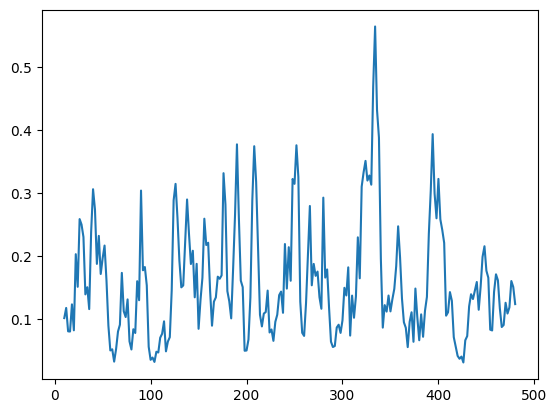

In [35]:
plt.plot(feat_df.index.get_level_values('time'),feat_df['sz_prob'])

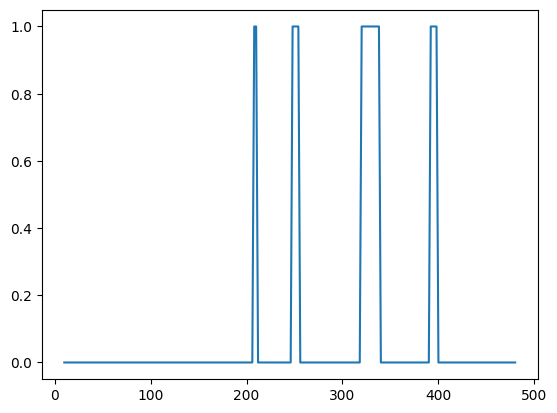

In [36]:
plt.plot(feat_df.index.get_level_values('time'),feat_df['pred'])

In [37]:
def sparcnet_pipeline():
    # some code to trigger detection once 2 seconds of data are available

    # suppose history seiz detection is stored in a variable
    history_prob = []
    history_feats = []
    while True: # every 2 seconds
        prob, feats = sparcnet_single(data,fs)
        history_prob.append(prob)
        history_feats.append(feats)

In [38]:
# test
edf_file_path = 'YASA/EMU1371_Day02_1_5006_to_5491.edf'
raw = mne.io.read_raw_edf(edf_file_path, preload=True)
fs = raw.info['sfreq']
clips = mne.make_fixed_length_epochs(raw, duration=10.0, overlap=8.0)
history_prob = []
history_feats = []
for i,clip in tqdm(enumerate(clips)):
    data = pd.DataFrame(clip.T, columns=raw.ch_names)
    prob, feats = sparcnet_single(data,fs,return_feats=True)
    history_prob.append(prob)
    history_feats.append(feats)

238it [00:01, 124.48it/s]


### Seizure Detector - intracranial

In [ ]:
# wavenet and will's, need to solve how to get non-seizure annotation
code_v2_path = os.path.dirname(working_dir+'/WVNT/')
sys.path.append(code_v2_path)
# from get_iEEG_data import *
from tensorflow.keras.models import load_model

from utils import *
from WVNT.model import WVNT
from WVNT.utils import *

feat_settings = {'name':'wvnt',
                'win':1, 'stride':0.5,
                'reref':'BIPOLAR', 'resample':128, 'fitting_dura':int(20*60)} # in seconds

wave_model = load_model(code_v2_path+'/v111.hdf5')
model = WVNT(wave_model)


In [40]:
def WVNT_single(data, fs, bad_mask):
    """Do seizure prediction on a 1-second clip.
    Data should be a pd dataframe

    Args:
        data (_type_): _description_
        fs (_type_): _description_
    """
    # chs = data.columns[bad_mask]
    data = data.values[:,bad_mask]

    # data = pre_whiten(data) # if haven't pre-whiten
    data = downsample(data, fs, feat_settings['resample'])
    pred = model(data)
    return pred


In [ ]:
threshold_block_seconds = int(4*3600)
threshold_calc_step_seconds = int(2*60)
min_thres_samples = 200 # should change to ~1800 for actual data
clip_loader = DatabaseFeatLoader('patient', 'wvnt')
fitting_stamp = feat_settings['fitting_dura']*clip_loader.fs
fitting_df = data_dfs[clip_loader.data_key].query(f'stamp <= {fitting_stamp}')
model.fit(fitting_df.values)
feat_df = pd.DataFrame()
for i,(feat_index, clip, bad_mask) in enumerate(clip_loader):
    prob = WVNT_single(clip, clip_loader.fs, bad_mask)
    prob_df = pd.DataFrame(prob, columns=clip.columns[bad_mask],index = feat_index)
    prob_df['Mean'] = np.nanmean(prob)
    feat_df = pd.concat([feat_df, prob_df])
    if (np.round(feat_index[0][0] * 2) / 2)%threshold_calc_step_seconds == 0:
        thres_df = feat_df.query(f'time >= {feat_index[0][0]-threshold_block_seconds}')[clip.columns]
        if thres_df.shape[0] >= min_thres_samples:
            thres = get_gaussianx_threshold(thres_df)
        else:
            thres = 0.5
        pred, spread = get_pred(thres_df.values, thres)
        feat_df.loc[thres_df.index,'thres'] = thres
        feat_df.loc[thres_df.index,'pred'] = pred
        feat_df.loc[thres_df.index,clip.columns+['_pred']] = spread
szs = extract_seiz_ranges(feat_df['pred'])
szs = [['Potential Seizure', 'WVNT']+[feat_df.index[sz[0]][1]]+[feat_df.index[sz[1]-1][1]-feat_df.index[sz[0]][1]+1] for sz in szs ]
event_df = pd.DataFrame(szs, columns=['Comment','Source','Start','Dura'])

In [42]:
feat_df

,,Fp1-F7,F7-T3,T3-T5,T5-O1,Fp2-F8,F8-T4,T4-T6,T6-O2,Fp1-F3,F3-C3,...,T6-O2_pred,Fp1-F3_pred,F3-C3_pred,C3-P3_pred,P3-O1_pred,Fp2-F4_pred,F4-C4_pred,C4-P4_pred,P4-O1_pred,Fz-Cz_pred
time,stamp,,,,,,,,,,,,,,,,,,,,,
0.996094,256,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.188882,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False
1.496094,384,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False
1.996094,512,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False
2.496094,640,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False
2.996094,768,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477.996094,122368,0.092409,0.076560,0.070839,0.070839,0.670833,0.070839,0.070839,0.070839,0.552863,0.070839,...,False,False,False,False,False,False,False,False,False,False
478.496094,122496,0.070839,0.070839,0.073445,0.070839,0.370347,0.070839,0.070839,0.070839,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False
478.996094,122624,0.070839,0.082670,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,0.070839,...,False,False,False,False,False,False,False,False,False,False


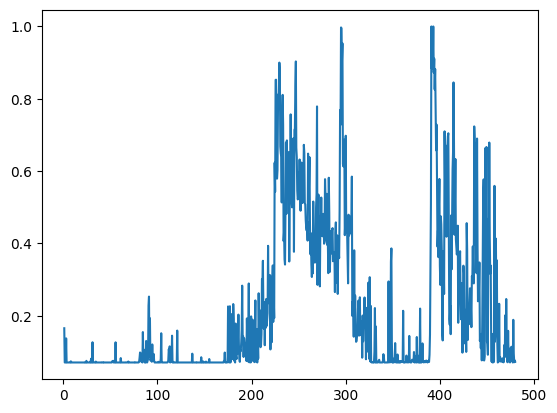

In [43]:
plt.plot(feat_df.index.get_level_values('time'),feat_df['Mean'].values)

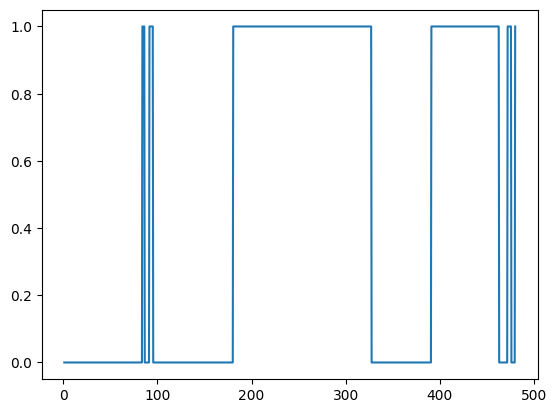

In [44]:
plt.plot(feat_df.index.get_level_values('time'),feat_df['pred'].values)

In [45]:
feat_df['thres'].mean()

np.float64(0.07510079640279875)

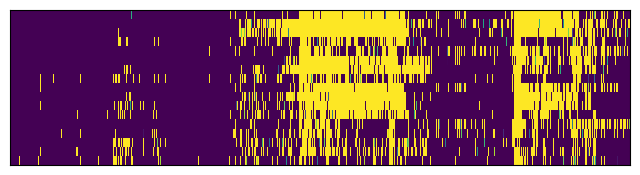

In [46]:
plt.matshow(feat_df.loc[:,clip.columns].T,interpolation='none', extent=[0, 20, 0, 5])
plt.xticks([])
plt.yticks([])
plt.clim([np.min(feat_df.loc[:,clip.columns]),feat_df['thres'].mean()])
# plt.gca().set_box_aspect(5 / 10)  # Aspect ratio based on data shape (rows/columns)

([], [])

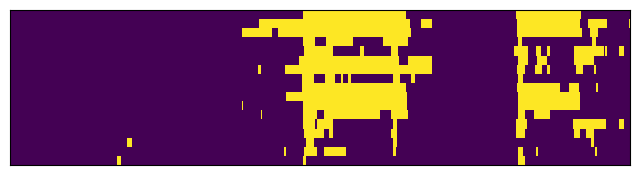

In [47]:
# Plot the seizure ictal wavefront after applying detection algorithm
plt.matshow(np.where(feat_df.loc[:,clip.columns+['_pred']].T,1,0),interpolation='none',extent=[0, 20, 0, 5])
plt.yticks([])
plt.xticks([])

In [48]:
def WVNT_pipeline():
    # some code to trigger detection once 0.5 seconds of data are available

    # suppose history seiz detection is stored in a variable
    history_prob = []
    model.fit(data)# initial e.g. 20 min of data
    while True: # every 2 seconds
        prob = WVNT_single(data,fs) 
        history_prob.append(prob)
        # actively check seizure event/duration/spread
        threshold = get_gaussianx_threshold(pd.DataFrame(np.array(history_prob)),noise_floor='automedian')
        pred, sz_spread_idxs_all = get_pred(np.array(history_prob), threshold)
        # save pred and sz_spread
        # save seizure duration and spread in a dict
        # also add this for sparcnet, though don't have per chan predictions